# Native GERG-2008 verification for hydrogen/methane

Hassanpouryouzband et al. published a hydrogen thermodynamic databank for
energy-storage studies. Their H2/CH4 table is a dense GERG-2008-generated
grid covering five compositions, two temperatures, and pressures from
0.01 to 100 MPa. This notebook reproduces density and isobaric heat capacity
for **all 1,010 tabulated states** with the native PyTorch GERG
implementation.

The bank is a model-reference reproduction, not experimental data. The
paper separately compares selected mixtures against experiment; keeping
these two kinds of evidence distinct avoids overstating validation.

Sources:

- Hydrogen thermodynamic databank:
  <https://doi.org/10.1038/s41597-020-0568-6>
- Public bank archive: <https://doi.org/10.6084/m9.figshare.12063297>
- GERG-2008: Kunz and Wagner, *J. Chem. Eng. Data* 57 (2012), 3032--3091,
  <https://doi.org/10.1021/je300655b>

In [1]:
from __future__ import annotations

from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from torch_flash.eos import GERG2008_COMPONENTS, gerg2008

torch.set_default_dtype(torch.float64)
REPO_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "pyproject.toml").is_file()
)
DATA = REPO_ROOT / "tests" / "data"
plt.style.use("seaborn-v0_8-whitegrid")

## Published parameter inventory

The complete native constructor contains all 21 GERG components and
${21 \choose 2}=210$ binary reducing-parameter sets. Fifteen pairs have a
non-zero explicit departure function.

In [2]:
full_model = gerg2008()
inventory = pd.Series(
    {
        "components": len(full_model.names),
        "binary reducing-parameter sets": len(full_model.names)
        * (len(full_model.names) - 1)
        // 2,
        "non-zero departure functions": int(
            torch.count_nonzero(
                torch.triu(full_model.departure_scale, diagonal=1)
            ).item()
        ),
    },
    name="GERG-2008",
)
display(inventory.to_frame())
print(", ".join(GERG2008_COMPONENTS))

assert inventory.to_dict() == {
    "components": 21,
    "binary reducing-parameter sets": 210,
    "non-zero departure functions": 15,
}

,GERG-2008
components,21
binary reducing-parameter sets,210
non-zero departure functions,15


methane, nitrogen, carbon_dioxide, ethane, propane, n_butane, isobutane, n_pentane, isopentane, n_hexane, n_heptane, n_octane, hydrogen, oxygen, carbon_monoxide, water, helium, argon, hydrogen_sulfide, n_nonane, n_decane


## Reproduce the full H2/CH4 bank

Each density is obtained from a nonlinear pressure-density solve; the
reference density is never used as an initial guess. The comparison
therefore exercises reducing rules, pure and departure Helmholtz terms,
PyTorch pressure autodiff, and density root finding.

In [3]:
bank = pd.read_csv(DATA / "gerg2008_h2_ch4_reference.csv")
model = gerg2008(("H2", "CH4"))

temperatures_tensor = torch.tensor(
    bank["temperature_K"].to_numpy(),
    dtype=torch.float64,
)
pressures_tensor = torch.tensor(bank["pressure_Pa"].to_numpy(), dtype=torch.float64)
hydrogen_tensor = torch.tensor(
    bank["hydrogen_mole_fraction"].to_numpy(),
    dtype=torch.float64,
)
compositions_tensor = torch.stack((hydrogen_tensor, 1.0 - hydrogen_tensor), dim=-1)

started = perf_counter()
molar_volumes = model.molar_volume(
    temperatures_tensor,
    pressures_tensor,
    compositions_tensor,
    "vapor",
)
mixture_molar_masses = torch.sum(
    compositions_tensor * model.molar_mass,
    dim=-1,
)
predicted_densities = mixture_molar_masses / molar_volumes
predicted_heat_capacities = (
    model.molar_heat_capacity_cp(
        temperatures_tensor,
        molar_volumes.reciprocal(),
        compositions_tensor,
    )
    / mixture_molar_masses
)
batched_seconds = perf_counter() - started

bank["predicted_density_kg_m3"] = predicted_densities.detach().numpy()
bank["predicted_heat_capacity_cp_J_kg_K"] = predicted_heat_capacities.detach().numpy()
print(
    f"Batched density + cp evaluation: {len(bank)} states in "
    f"{batched_seconds:.3f} s ({len(bank) / batched_seconds:,.0f} states/s)"
)
bank["relative_deviation_percent"] = (
    100.0
    * (bank["predicted_density_kg_m3"] - bank["density_kg_m3"])
    / bank["density_kg_m3"]
)
bank["heat_capacity_relative_deviation_percent"] = (
    100.0
    * (bank["predicted_heat_capacity_cp_J_kg_K"] - bank["heat_capacity_cp_J_kg_K"])
    / bank["heat_capacity_cp_J_kg_K"]
)

assert len(bank) == 1_010

Batched density + cp evaluation: 1010 states in 0.759 s (1,330 states/s)


### Density curves, predicted-versus-reference, and deviations

Reference markers are thinned only in the first plot for legibility; every
state remains present in the predicted-versus-reference and deviation
panels and in all reported metrics.

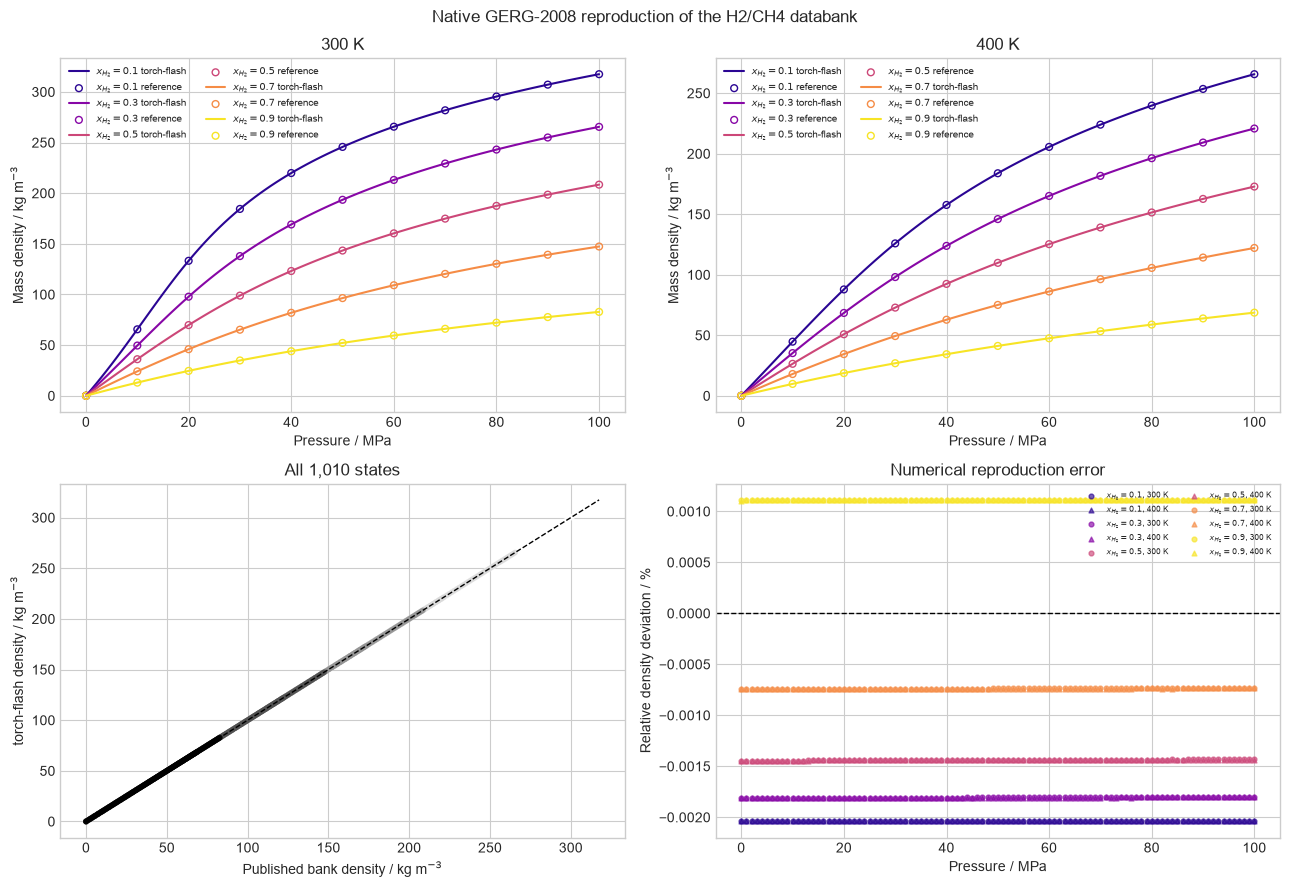

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
temperatures = sorted(bank["temperature_K"].unique())
colors = plt.cm.plasma(
    torch.linspace(0.05, 0.95, bank["hydrogen_mole_fraction"].nunique()).numpy()
)

for axis, temperature in zip(axes[0], temperatures, strict=True):
    subset_temperature = bank[bank["temperature_K"] == temperature]
    for color, (hydrogen, group) in zip(
        colors,
        subset_temperature.groupby("hydrogen_mole_fraction"),
        strict=True,
    ):
        group = group.sort_values("pressure_Pa")
        axis.plot(
            group["pressure_Pa"] / 1.0e6,
            group["predicted_density_kg_m3"],
            color=color,
            linewidth=1.5,
            label=f"$x_{{H_2}}={hydrogen:.1f}$ torch-flash",
        )
        axis.scatter(
            group["pressure_Pa"].iloc[::10] / 1.0e6,
            group["density_kg_m3"].iloc[::10],
            facecolors="none",
            edgecolors=[color],
            s=24,
            label=f"$x_{{H_2}}={hydrogen:.1f}$ reference",
        )
    axis.set(
        xlabel="Pressure / MPa",
        ylabel="Mass density / kg m$^{-3}$",
        title=f"{temperature:.0f} K",
    )
    axis.legend(ncol=2, fontsize=7)

axes[1, 0].scatter(
    bank["density_kg_m3"],
    bank["predicted_density_kg_m3"],
    c=bank["hydrogen_mole_fraction"],
    s=10,
    alpha=0.7,
)
density_limits = [
    bank[["density_kg_m3", "predicted_density_kg_m3"]].min().min(),
    bank[["density_kg_m3", "predicted_density_kg_m3"]].max().max(),
]
axes[1, 0].plot(density_limits, density_limits, "k--", linewidth=1)
axes[1, 0].set(
    xlabel="Published bank density / kg m$^{-3}$",
    ylabel="torch-flash density / kg m$^{-3}$",
    title="All 1,010 states",
)

for color, (hydrogen, group) in zip(
    colors, bank.groupby("hydrogen_mole_fraction"), strict=True
):
    for temperature, marker in ((300, "o"), (400, "^")):
        state = group[group["temperature_K"] == temperature]
        axes[1, 1].scatter(
            state["pressure_Pa"] / 1.0e6,
            state["relative_deviation_percent"],
            color=color,
            marker=marker,
            s=12,
            alpha=0.65,
            label=f"$x_{{H_2}}={hydrogen:.1f}$, {temperature} K",
        )
axes[1, 1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set(
    xlabel="Pressure / MPa",
    ylabel="Relative density deviation / %",
    title="Numerical reproduction error",
)
axes[1, 1].legend(ncol=2, fontsize=6)

fig.suptitle("Native GERG-2008 reproduction of the H2/CH4 databank")
fig.tight_layout()
plt.show()

### Caloric-property reproduction

Heat capacity requires the pure ideal-gas functions and second Helmholtz
derivatives. It therefore checks model content that a density-only
comparison cannot exercise.

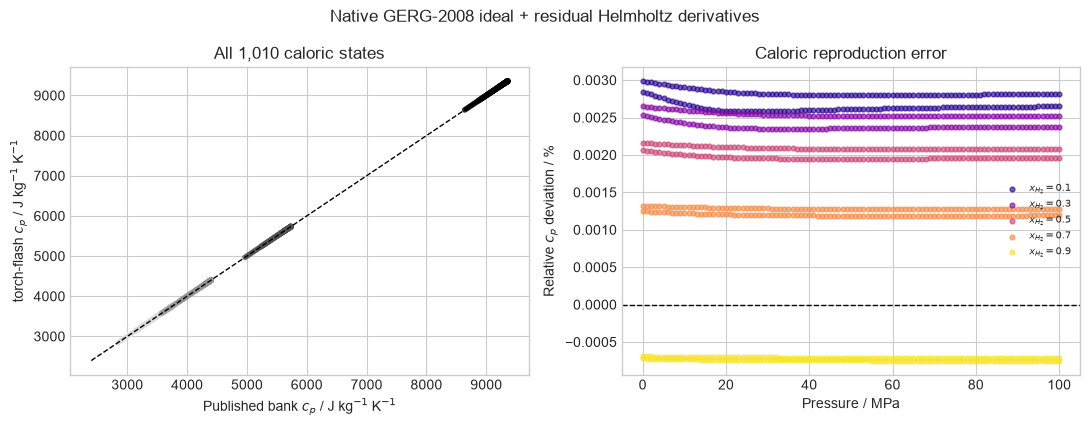

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].scatter(
    bank["heat_capacity_cp_J_kg_K"],
    bank["predicted_heat_capacity_cp_J_kg_K"],
    c=bank["hydrogen_mole_fraction"],
    s=10,
    alpha=0.7,
)
cp_limits = [
    bank[["heat_capacity_cp_J_kg_K", "predicted_heat_capacity_cp_J_kg_K"]].min().min(),
    bank[["heat_capacity_cp_J_kg_K", "predicted_heat_capacity_cp_J_kg_K"]].max().max(),
]
axes[0].plot(cp_limits, cp_limits, "k--", linewidth=1)
axes[0].set(
    xlabel="Published bank $c_p$ / J kg$^{-1}$ K$^{-1}$",
    ylabel="torch-flash $c_p$ / J kg$^{-1}$ K$^{-1}$",
    title="All 1,010 caloric states",
)
for color, (hydrogen, group) in zip(
    colors, bank.groupby("hydrogen_mole_fraction"), strict=True
):
    axes[1].scatter(
        group["pressure_Pa"] / 1.0e6,
        group["heat_capacity_relative_deviation_percent"],
        color=color,
        s=12,
        alpha=0.65,
        label=f"$x_{{H_2}}={hydrogen:.1f}$",
    )
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set(
    xlabel="Pressure / MPa",
    ylabel="Relative $c_p$ deviation / %",
    title="Caloric reproduction error",
)
axes[1].legend(fontsize=7)
fig.suptitle("Native GERG-2008 ideal + residual Helmholtz derivatives")
fig.tight_layout()
plt.show()

In [6]:
metrics = pd.Series(
    {
        "states": len(bank),
        "temperatures": bank["temperature_K"].nunique(),
        "hydrogen compositions": bank["hydrogen_mole_fraction"].nunique(),
        "minimum pressure / MPa": bank["pressure_Pa"].min() / 1.0e6,
        "maximum pressure / MPa": bank["pressure_Pa"].max() / 1.0e6,
        "AARD / %": bank["relative_deviation_percent"].abs().mean(),
        "maximum absolute relative deviation / %": bank["relative_deviation_percent"]
        .abs()
        .max(),
        "heat-capacity AARD / %": bank["heat_capacity_relative_deviation_percent"]
        .abs()
        .mean(),
        "heat-capacity maximum absolute relative deviation / %": bank[
            "heat_capacity_relative_deviation_percent"
        ]
        .abs()
        .max(),
    }
)
display(metrics.to_frame("value"))
assert bank["relative_deviation_percent"].abs().mean() < 0.0015
assert bank["relative_deviation_percent"].abs().max() < 0.003
assert bank["heat_capacity_relative_deviation_percent"].abs().mean() < 0.0019
assert bank["heat_capacity_relative_deviation_percent"].abs().max() < 0.003

,value
states,1010.000000
temperatures,2.000000
hydrogen compositions,5.000000
minimum pressure / MPa,0.010000
maximum pressure / MPa,100.000000
AARD / %,0.001427
maximum absolute relative deviation / %,0.002041
heat-capacity AARD / %,0.001837
heat-capacity maximum absolute relative deviation / %,0.002987


## Composition sensitivity by autodiff

This derivative includes the implicit density solve. `torch.func.jacfwd`
differentiates the final density with respect to hydrogen mole fraction at
fixed temperature and pressure.

In [7]:
temperature = torch.tensor(300.0)
pressure = torch.tensor(20.0e6)


def mass_density(hydrogen_fraction: torch.Tensor) -> torch.Tensor:
    composition = torch.stack((hydrogen_fraction, 1.0 - hydrogen_fraction))
    volume = model.molar_volume(temperature, pressure, composition, "vapor")
    return torch.dot(composition, model.molar_mass) / volume


hydrogen_fraction = torch.tensor(0.5)
state_density = mass_density(hydrogen_fraction)
density_sensitivity = torch.func.jacfwd(mass_density)(hydrogen_fraction)
print(f"rho(300 K, 20 MPa, x_H2=0.5) = {float(state_density):.8f} kg/m³")
print(f"d rho / d x_H2 = {float(density_sensitivity):.8f} kg/m³")
assert torch.isfinite(density_sensitivity)

rho(300 K, 20 MPa, x_H2=0.5) = 69.79750731 kg/m³
d rho / d x_H2 = -127.67301751 kg/m³


## Interpretation and limitations

- All 1,010 bank states are reproduced to below 0.003% maximum relative
  deviation in both density and heat capacity; the small residual is
  consistent with decimal truncation and historical gas-constant precision
  in the published text file.
- This is strong implementation regression evidence because it spans a
  dense state grid. It is not independent experimental validation because
  the source bank itself was generated with GERG-2008.
- The paper's experimental comparisons are useful external evidence for
  GERG in hydrogen mixtures, but those plot-only points are not silently
  digitized or relabeled as the bank data here.